In [1]:
import sys
sys.path.insert(1, '../')

In [2]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functions.analysis import create_df, best_performance_summary
from functions.plotting import compute_ylim

## Datasets

In [3]:
datasets = ["glass-0-1-4-6_vs_2", "pima", "ozone_level", "scene"]

## Load results

In [4]:
filename = '../models/ensembles/results'
with open(filename, 'rb') as f:
    scores_dict = pickle.load(f)

scores_dict = {key: scores_dict[key] for key in datasets}

scores_dict.keys()

dict_keys(['glass-0-1-4-6_vs_2', 'pima', 'ozone_level', 'scene'])

In [5]:
base_dir = '../models/oversampling'

oversamplers = [
    'ros_equal',
    'ros_half',
    'ros_shrink01_equal',
    'ros_shrink01_half',
    'ros_shrink1_equal',
    'ros_shrink1_half',
    'smote_equal',
    'smote_half',
    'adasyn_equal',
    'adasyn_half',
    'bsmote1_equal',
    'bsmote1_half',
    'bsmote2_equal',
    'bsmote2_half',
]

for oversampler in oversamplers:
    file_path = f'{base_dir}/results_{oversampler}'
    with open(file_path, 'rb') as f:
        tmp = pickle.load(f)

    scores_dict = {
        key: {**scores_dict[key], **tmp[key]}
        for key in scores_dict
    }

In [8]:
# test function
data = "glass-0-1-4-6_vs_2"
models = scores_dict[data].keys()

df = create_df(scores_dict, data, models)
df

,roc,roc_std,ap,ap_std,precision,precision_std,recall,recall_std,f1_score,f1_std,mcc,mcc_std,ba,ba_std,brier,brier_std,gmean,gmean_std,thresh,tresh_std
rf,0.828036,0.098593,0.312785,0.260841,0.293737,0.242341,1.00,0.00,0.403030,0.273171,0.455667,0.227336,0.906518,0.044438,0.049158,0.020896,0.900390,0.048313,1.801887e-01,1.289436e-01
ada,0.760278,0.168297,0.359947,0.377165,0.357003,0.375442,0.96,0.08,0.412991,0.359285,0.450285,0.316995,0.870139,0.077193,0.167458,0.005663,0.855876,0.088052,4.543149e-01,4.457106e-02
gbm,0.786667,0.126227,0.372821,0.373971,0.450769,0.448524,0.88,0.24,0.407792,0.337323,0.466303,0.302022,0.883333,0.061237,0.046756,0.028629,0.873009,0.067248,3.997561e-01,4.895990e-01
cat,0.798611,0.146065,0.397633,0.394345,0.360808,0.368430,1.00,0.00,0.434524,0.357024,0.482306,0.314665,0.893056,0.067985,0.093421,0.025994,0.883365,0.076013,2.008742e-01,3.968942e-01
lgbm,0.612500,0.294903,0.333000,0.377375,0.331667,0.376770,0.96,0.08,0.382749,0.368902,0.400858,0.343565,0.792500,0.140528,0.086717,0.032152,0.742375,0.197177,1.998885e-01,3.996859e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ada_bsmote2_half,0.462183,0.206916,0.062914,0.039194,0.067869,0.048618,1.00,0.00,0.123425,0.080961,0.114152,0.043900,0.613829,0.054654,0.121748,0.015198,0.459492,0.128551,3.170415e-01,1.010169e-02
gbm_bsmote2_half,0.472460,0.187307,0.080587,0.045875,0.083849,0.051768,1.00,0.00,0.150683,0.084673,0.168790,0.059079,0.693284,0.084715,0.053799,0.041670,0.615439,0.151006,2.382999e-03,1.367167e-04
cat_bsmote2_half,0.467480,0.138114,0.079234,0.052407,0.084567,0.062161,1.00,0.00,0.150215,0.100064,0.169805,0.066808,0.688849,0.038584,0.054293,0.041670,0.611145,0.064805,1.183679e-03,1.784363e-04
lgbm_bsmote2_half,0.447192,0.142885,0.070174,0.046564,0.074556,0.054304,1.00,0.00,0.134212,0.090139,0.135148,0.063292,0.637381,0.061059,0.054054,0.041870,0.508430,0.127519,3.688443e-13,2.493123e-13


## Plot ROC-AUC

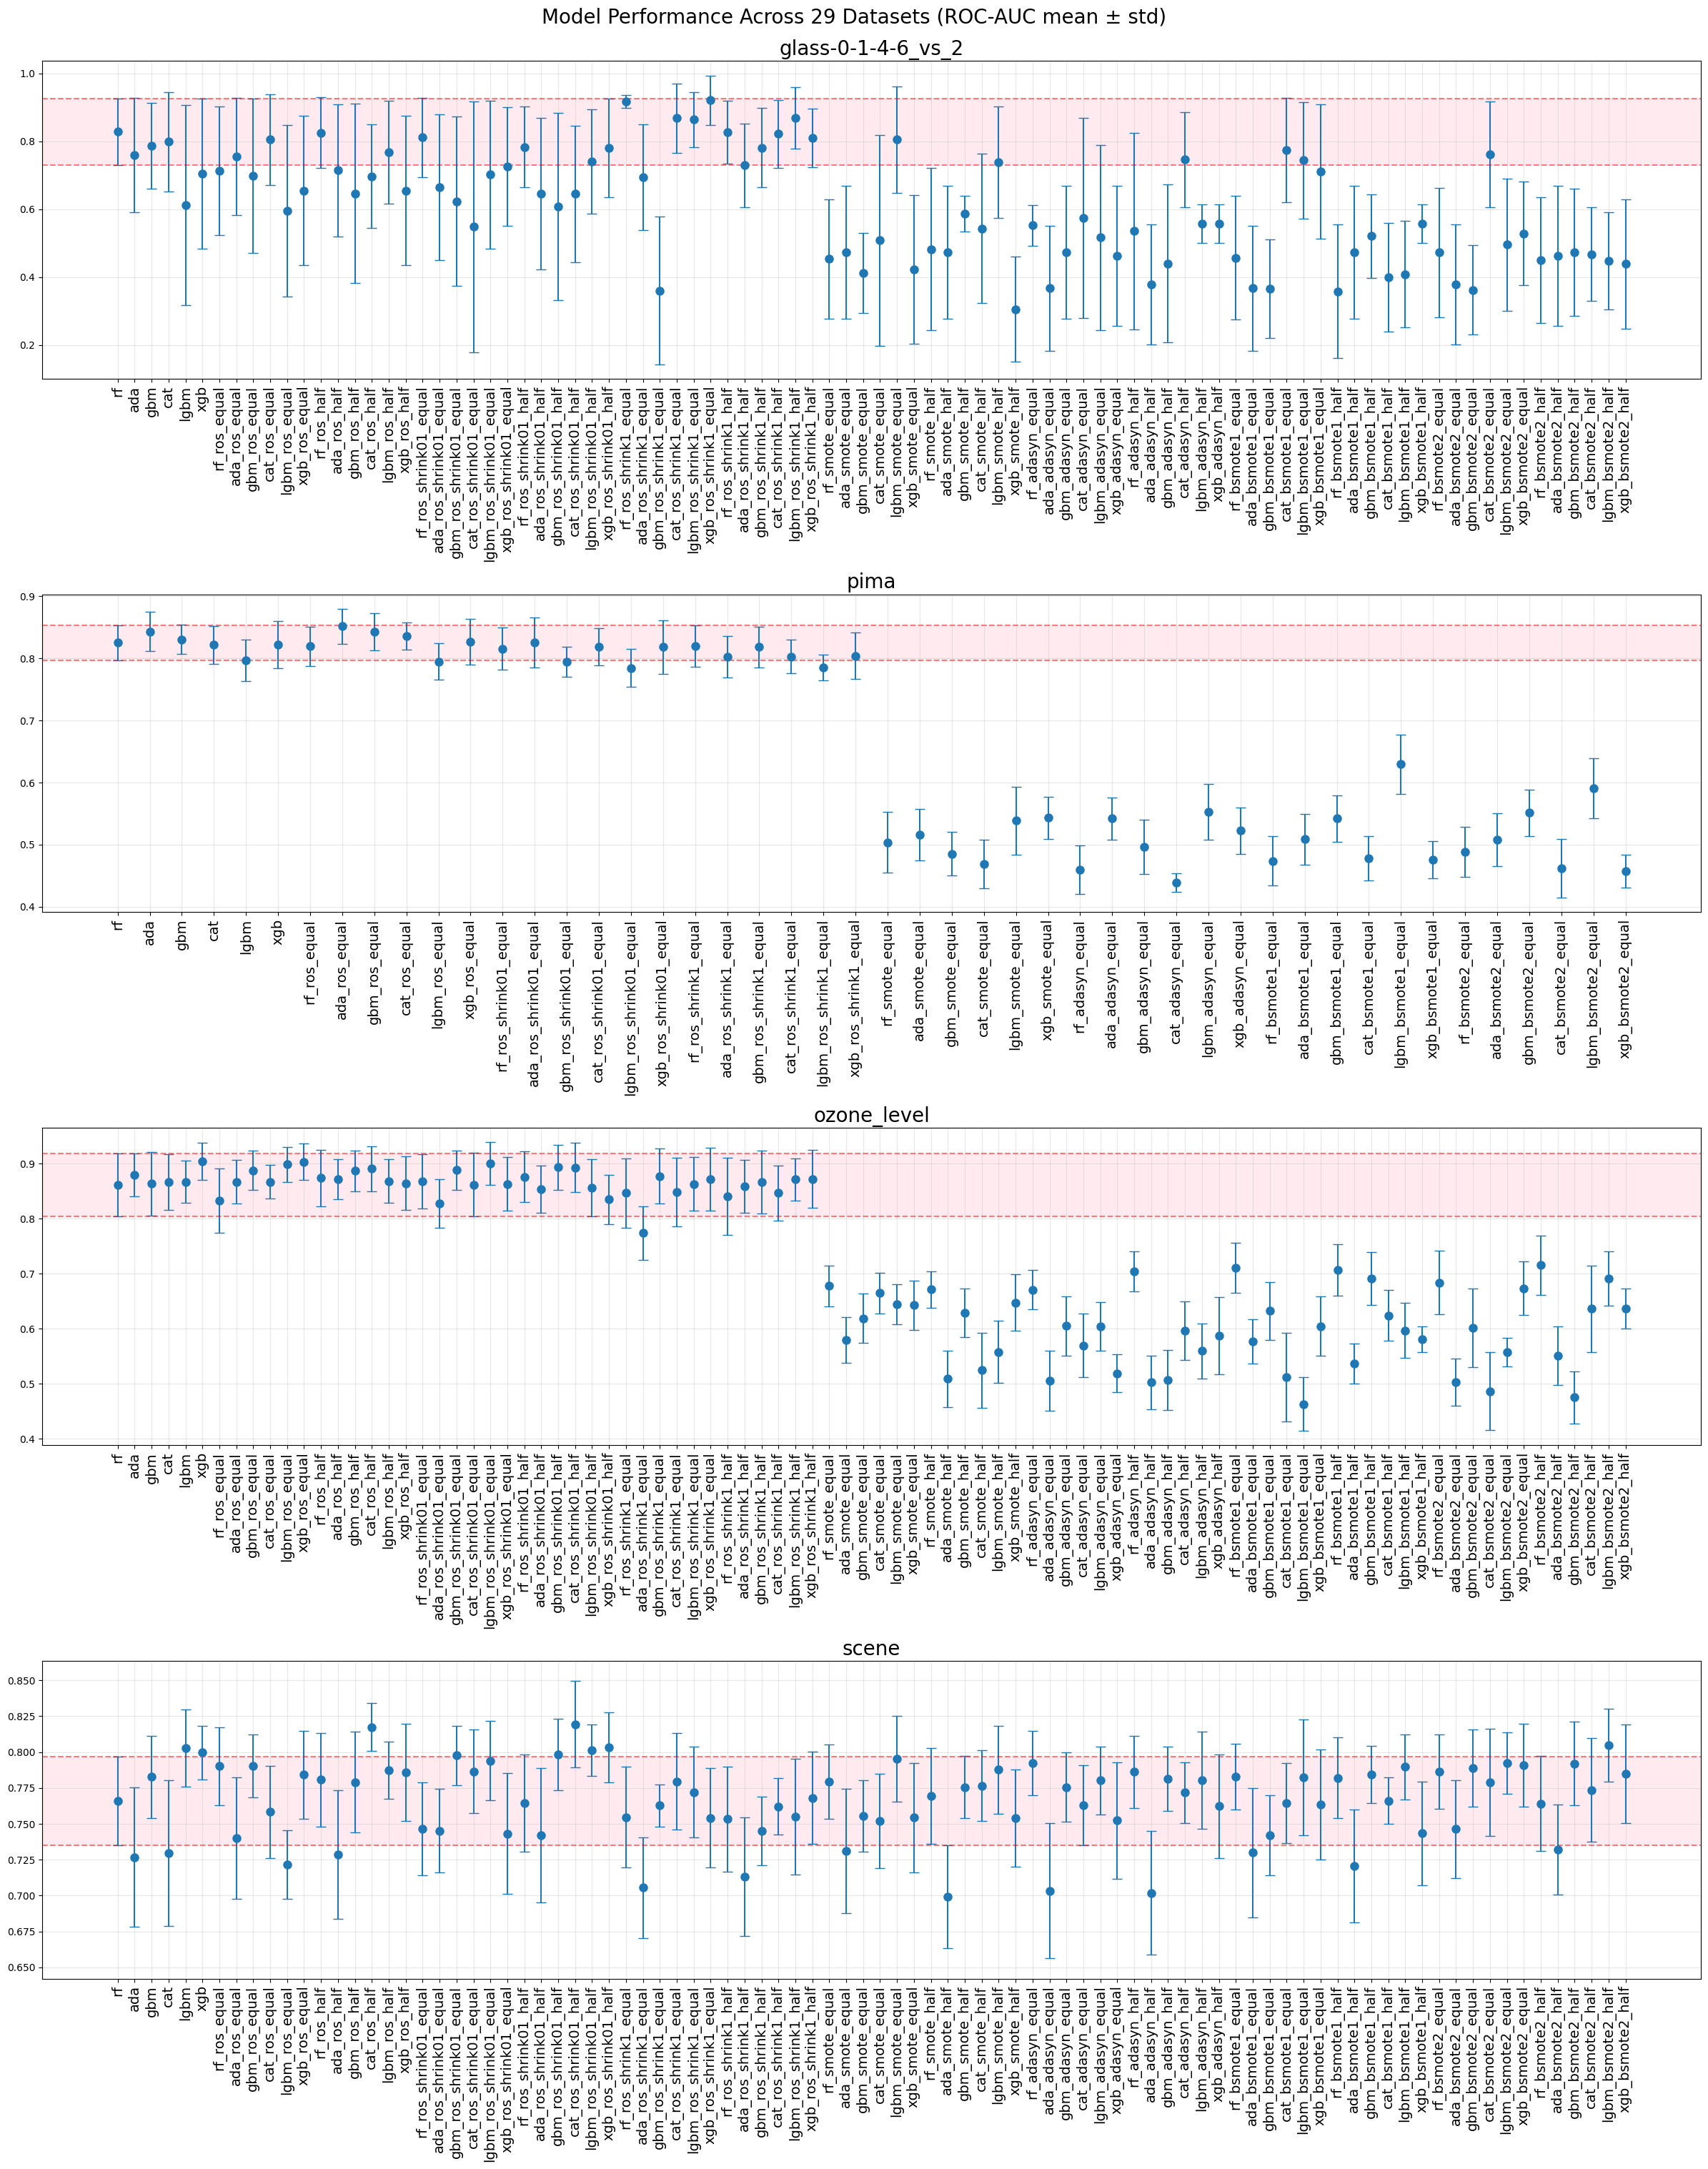

In [13]:
fig, axes = plt.subplots(nrows=len(datasets), ncols=1, figsize=(24, 30))
axes = axes.ravel()

for i, data in enumerate(datasets):
    models = scores_dict[data].keys()
    df = create_df(scores_dict, data, models)

    ax = axes[i]

    cls = df.index
    means = df.iloc[:, 0]
    stds = df.iloc[:, 1]

    upper = df.iloc[0, 0] + df.iloc[0, 1]
    lower = df.iloc[0, 0] - df.iloc[0, 1]

    ax.errorbar(x=cls, y=means, yerr=stds, fmt='o', capsize=5, markersize=8)

    ax.set_title(data, fontsize=20)
    ylims = compute_ylim(means, stds, upper, lower)
    ax.set_ylim(ylims)
    ax.tick_params(axis='x', rotation=90, labelsize=14)
    ax.grid(True, alpha=0.3)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

plt.tight_layout()
plt.suptitle('Model Performance Across 4 Datasets (ROC-AUC mean ± std)', fontsize=20, y=1.01)
plt.savefig('../figures/os_rocauc.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot average precision

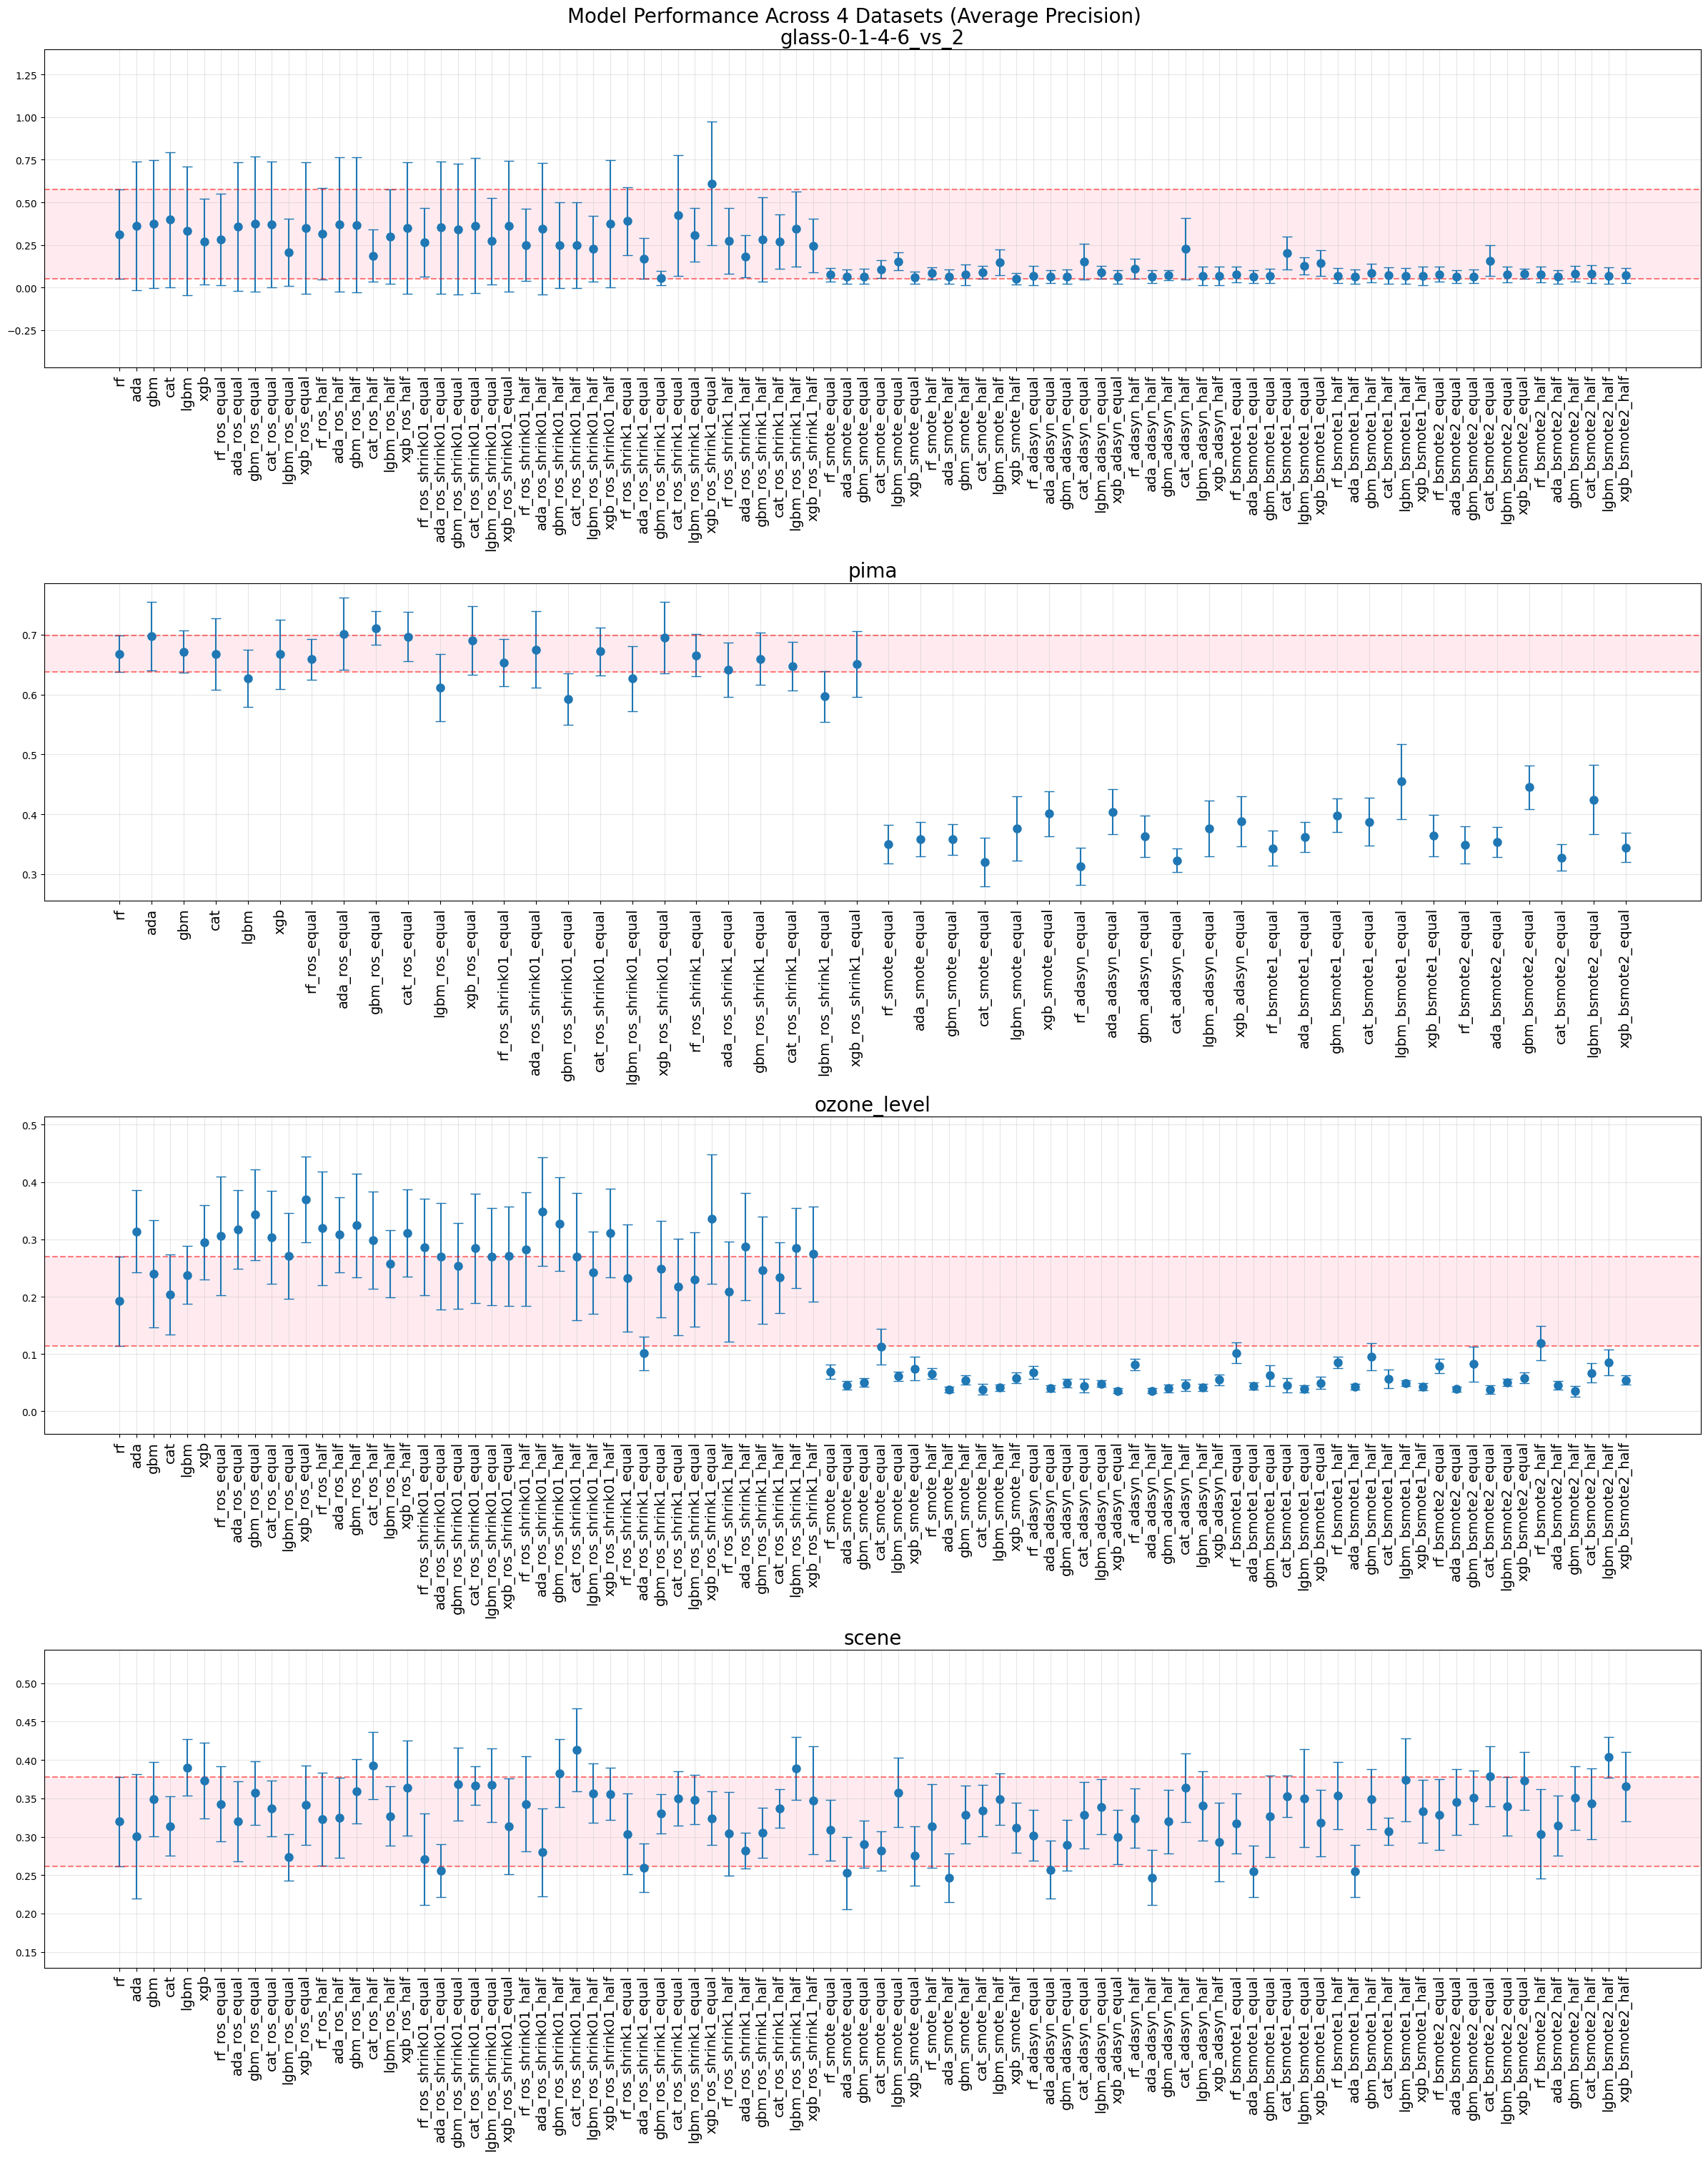

In [14]:
fig, axes = plt.subplots(nrows=len(datasets), ncols=1, figsize=(24, 30))
axes = axes.ravel()

for i, data in enumerate(datasets):
    models = scores_dict[data].keys()
    df = create_df(scores_dict, data, models)

    ax = axes[i]

    cls = df.index
    means = df.iloc[:, 2]
    stds = df.iloc[:, 3]

    upper = df.iloc[0, 2] + df.iloc[0, 3]
    lower = df.iloc[0, 2] - df.iloc[0, 3]

    ax.errorbar(x=cls, y=means, yerr=stds, fmt='o', capsize=5, markersize=8)

    ax.set_title(data, fontsize=20)
    ylims = compute_ylim(means, stds, upper, lower)
    ax.set_ylim(ylims)
    ax.tick_params(axis='x', rotation=90, labelsize=14)
    ax.grid(True, alpha=0.3)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

plt.tight_layout()
plt.suptitle('Model Performance Across 4 Datasets (Average Precision)', fontsize=20, y=1.005)
plt.savefig('../figures/os_ap.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot Recall

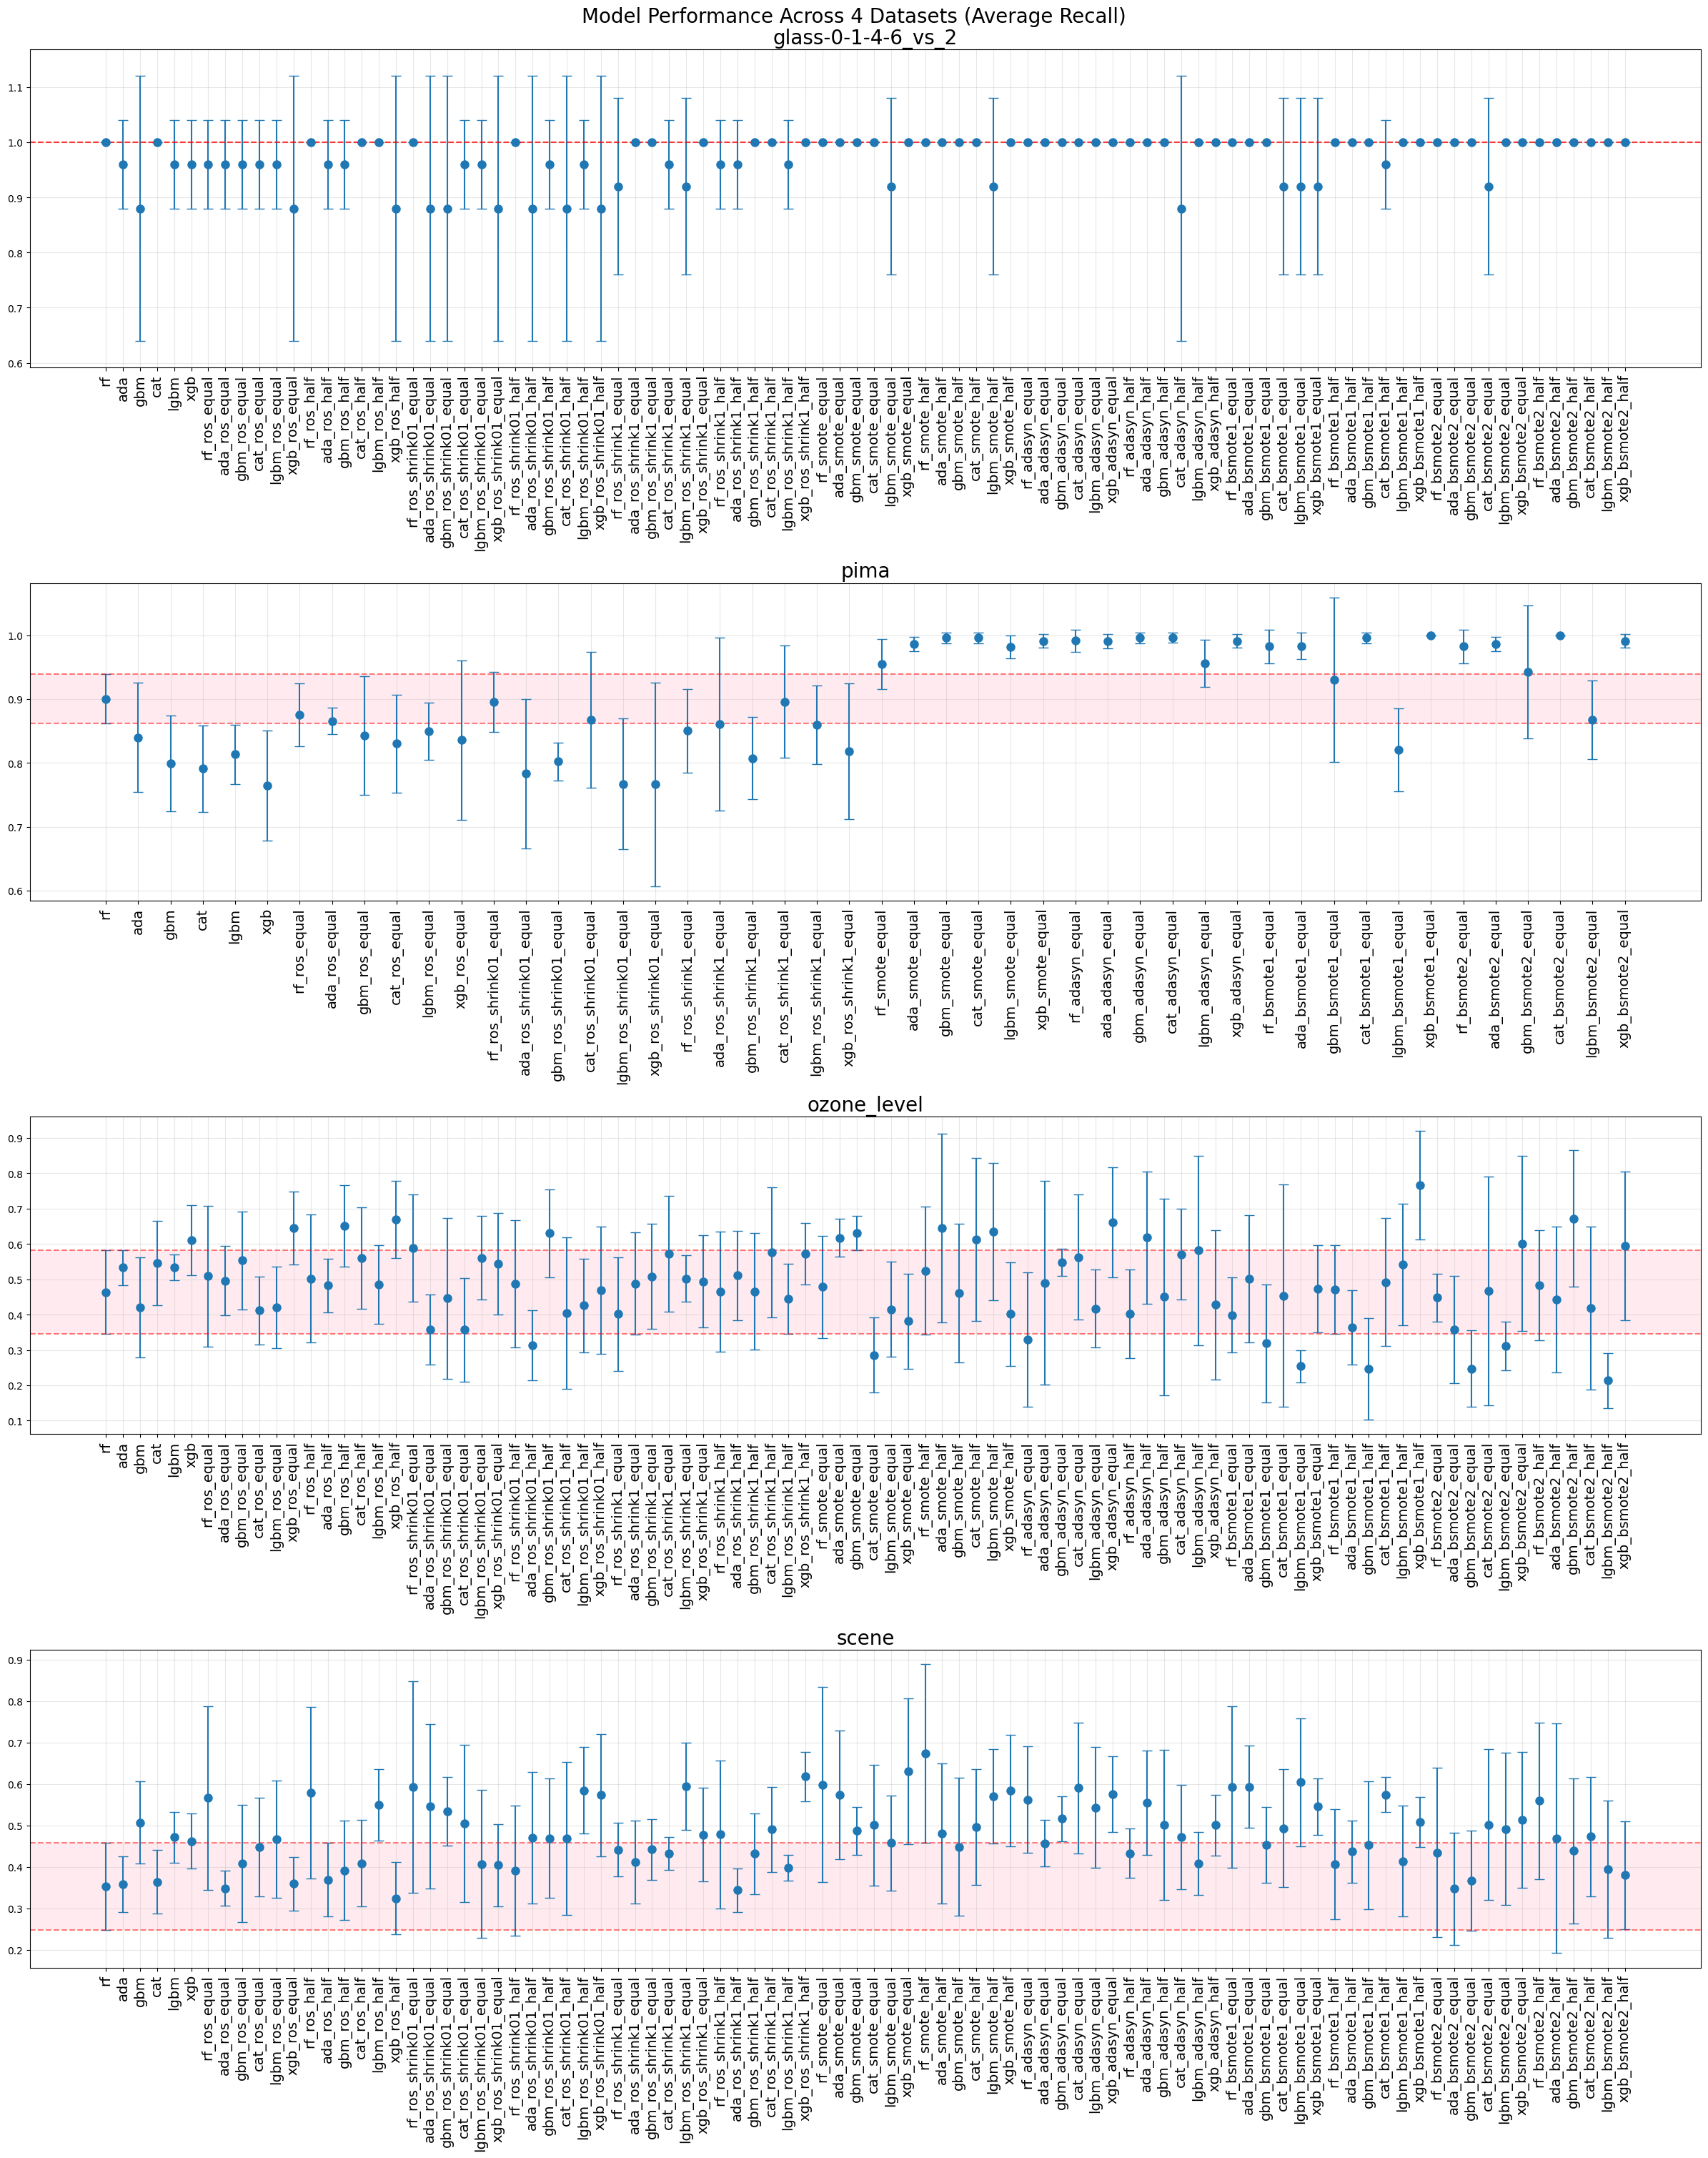

In [15]:
fig, axes = plt.subplots(nrows=len(datasets), ncols=1, figsize=(24, 30))
axes = axes.ravel()

for i, data in enumerate(datasets):
    models = scores_dict[data].keys()
    df = create_df(scores_dict, data, models)

    ax = axes[i]

    cls = df.index
    means = df.iloc[:, 6]
    stds = df.iloc[:, 7]

    upper = df.iloc[0, 6] + df.iloc[0, 7]
    lower = df.iloc[0, 6] - df.iloc[0, 7]

    ax.errorbar(x=cls, y=means, yerr=stds, fmt='o', capsize=5, markersize=8)

    ax.set_title(data, fontsize=20)
    ylims = compute_ylim(means, stds, upper, lower)
    ax.set_ylim(ylims)
    ax.tick_params(axis='x', rotation=90, labelsize=14)
    ax.grid(True, alpha=0.3)

    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

plt.tight_layout()
plt.suptitle('Model Performance Across 4 Datasets (Average Recall)', fontsize=20, y=1.005)
plt.savefig('../figures/os_recall.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot f1-score

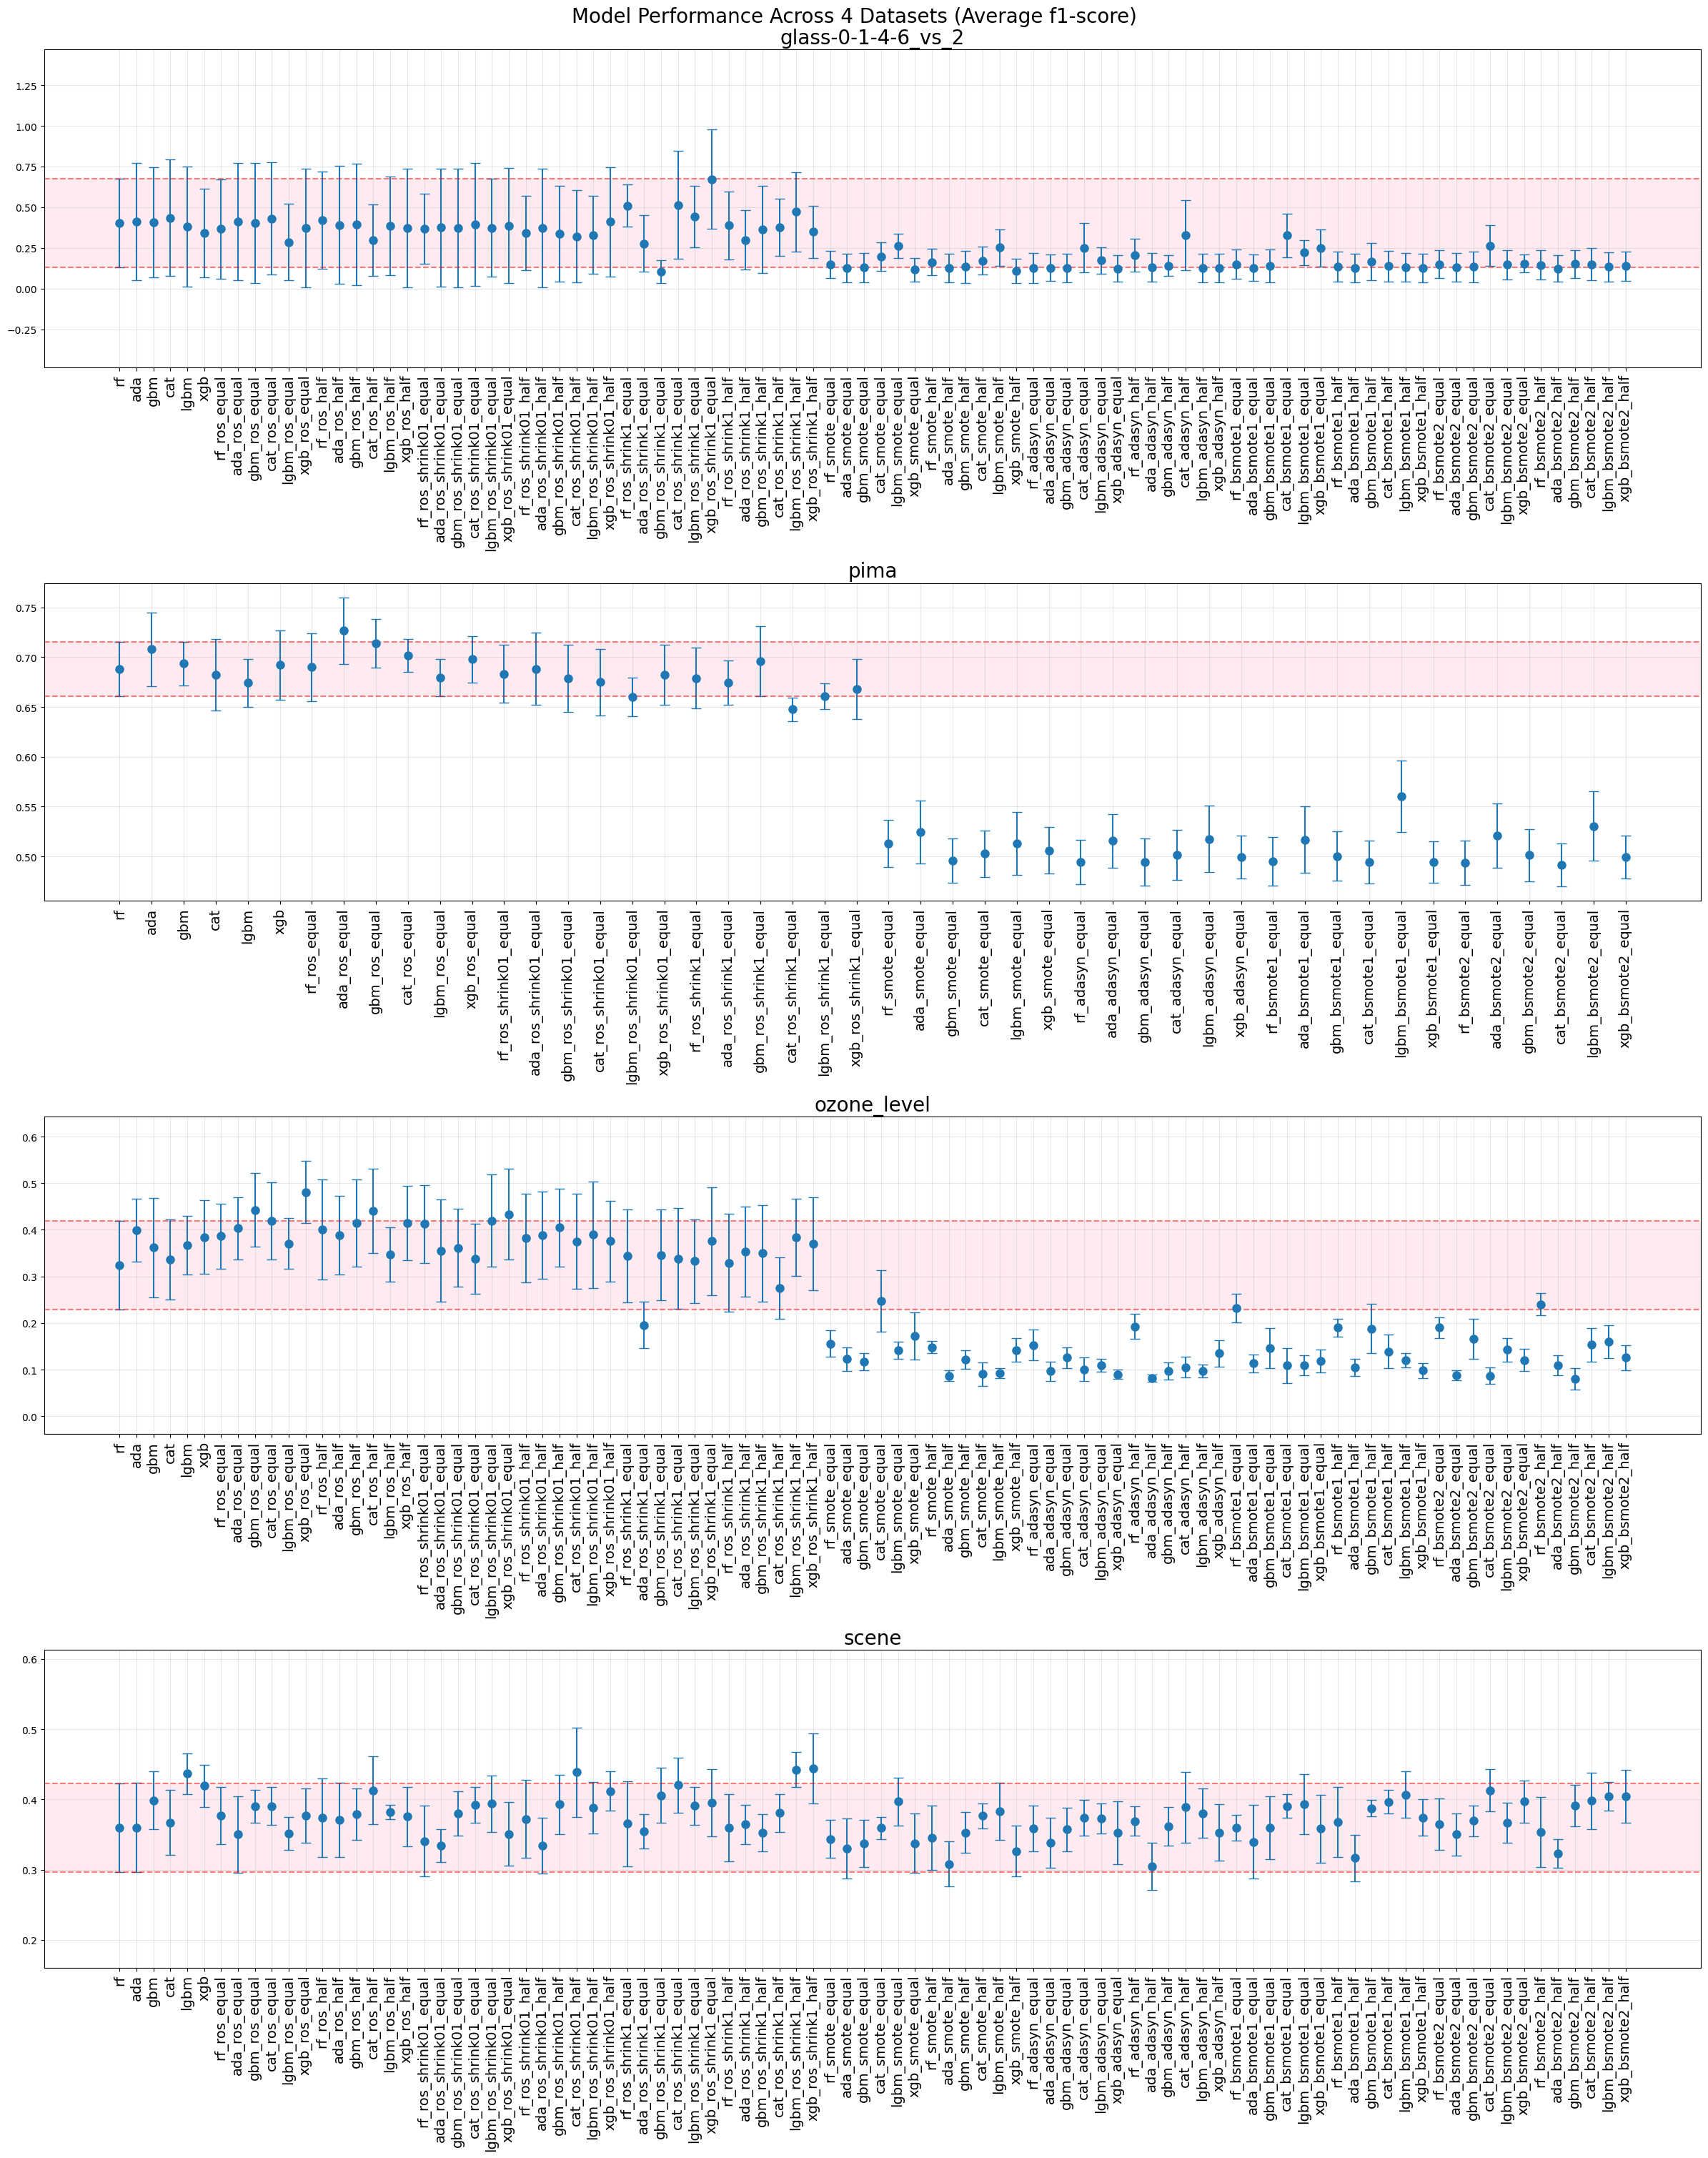

In [16]:
fig, axes = plt.subplots(nrows=len(datasets), ncols=1, figsize=(24, 30))
axes = axes.ravel()

for i, data in enumerate(datasets):
    models = scores_dict[data].keys()
    df = create_df(scores_dict, data, models)

    ax = axes[i]

    cls = df.index
    means = df.iloc[:, 8]
    stds = df.iloc[:, 9]

    upper = df.iloc[0, 8] + df.iloc[0, 9]
    lower = df.iloc[0, 8] - df.iloc[0, 9]

    ax.errorbar(x=cls, y=means, yerr=stds, fmt='o', capsize=5, markersize=8)

    ax.set_title(data, fontsize=20)
    ylims = compute_ylim(means, stds, upper, lower)
    ax.set_ylim(ylims)
    ax.tick_params(axis='x', rotation=90, labelsize=14)
    ax.grid(True, alpha=0.3)

    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

plt.tight_layout()
plt.suptitle('Model Performance Across 4 Datasets (Average f1-score)', fontsize=20, y=1.005)
plt.savefig('../figures/os_f1.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot MCC

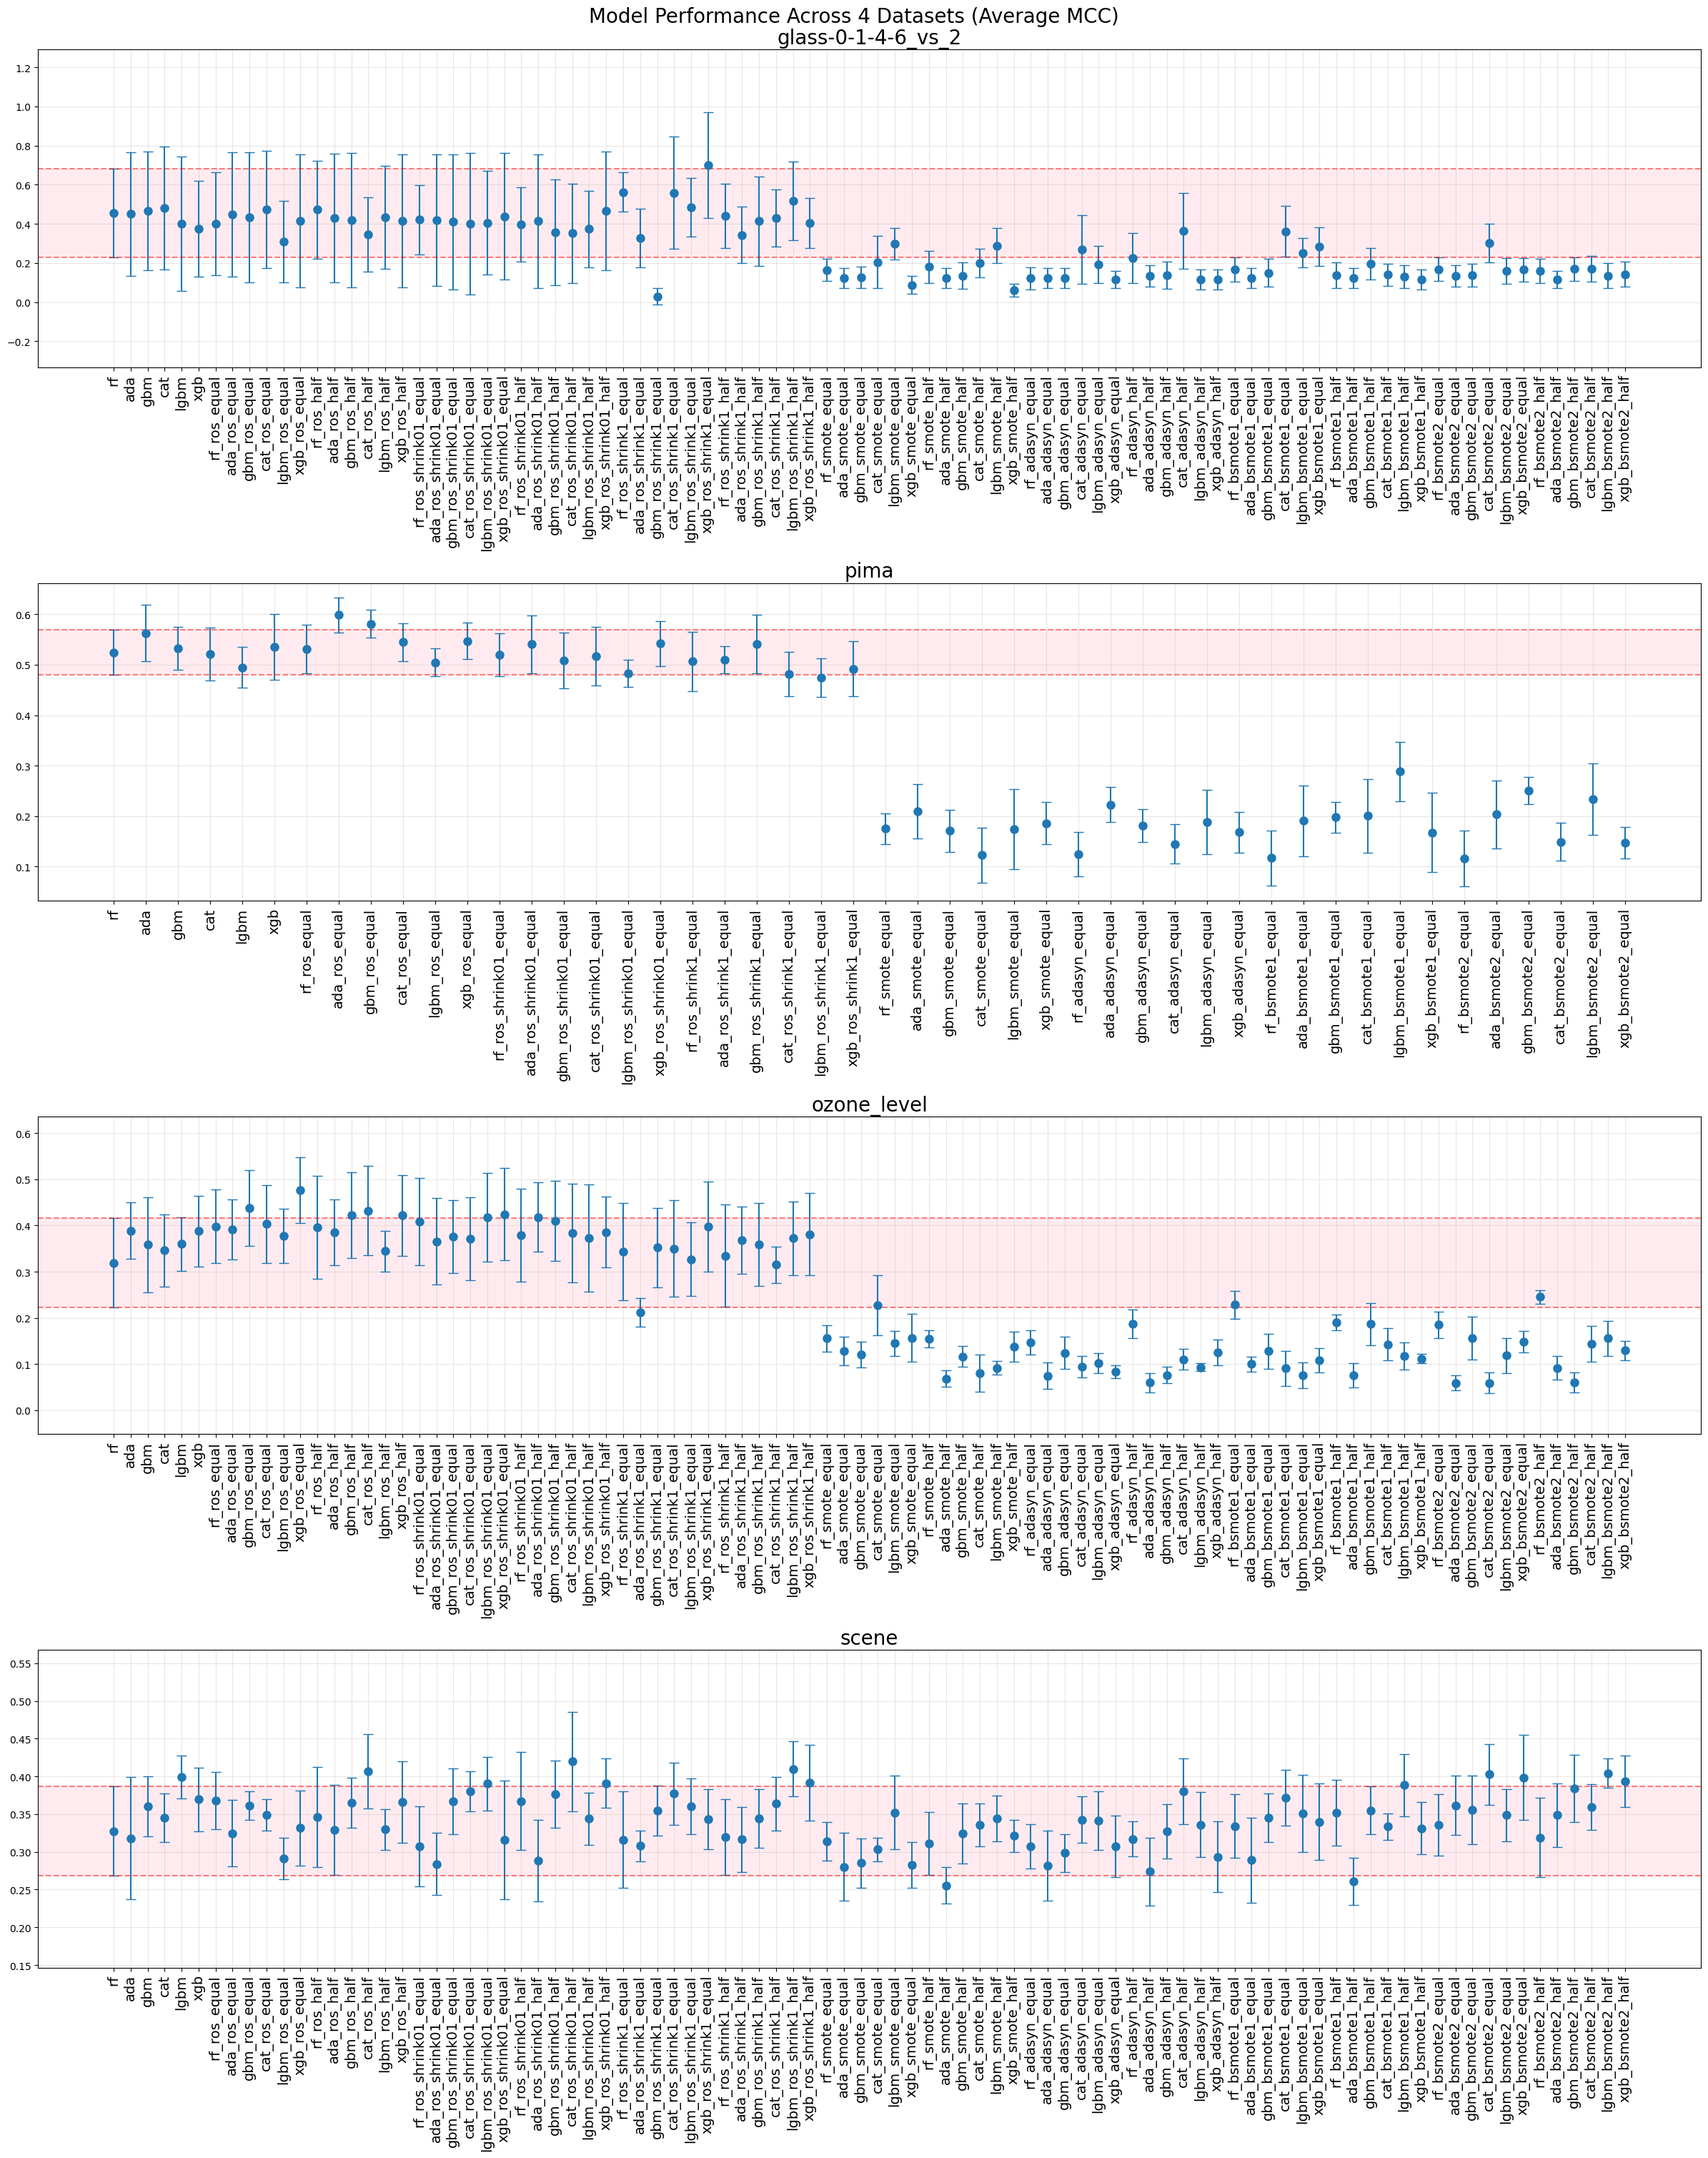

In [17]:
fig, axes = plt.subplots(nrows=len(datasets), ncols=1, figsize=(24, 30))
axes = axes.ravel()

for i, data in enumerate(datasets):
    models = scores_dict[data].keys()
    df = create_df(scores_dict, data, models)

    ax = axes[i]

    cls = df.index
    means = df.iloc[:, 10]
    stds = df.iloc[:, 11]

    upper = df.iloc[0, 10] + df.iloc[0, 11]
    lower = df.iloc[0, 10] - df.iloc[0, 11]

    ax.errorbar(x=cls, y=means, yerr=stds, fmt='o', capsize=5, markersize=8)

    ax.set_title(data, fontsize=20)
    ylims = compute_ylim(means, stds, upper, lower)
    ax.set_ylim(ylims)
    ax.tick_params(axis='x', rotation=90, labelsize=14)
    ax.grid(True, alpha=0.3)

    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

plt.tight_layout()
plt.suptitle('Model Performance Across 4 Datasets (Average MCC)', fontsize=20, y=1.005)
plt.savefig('../figures/os_mcc.png', dpi=300, bbox_inches='tight')
plt.show()

## Balanced accuracy

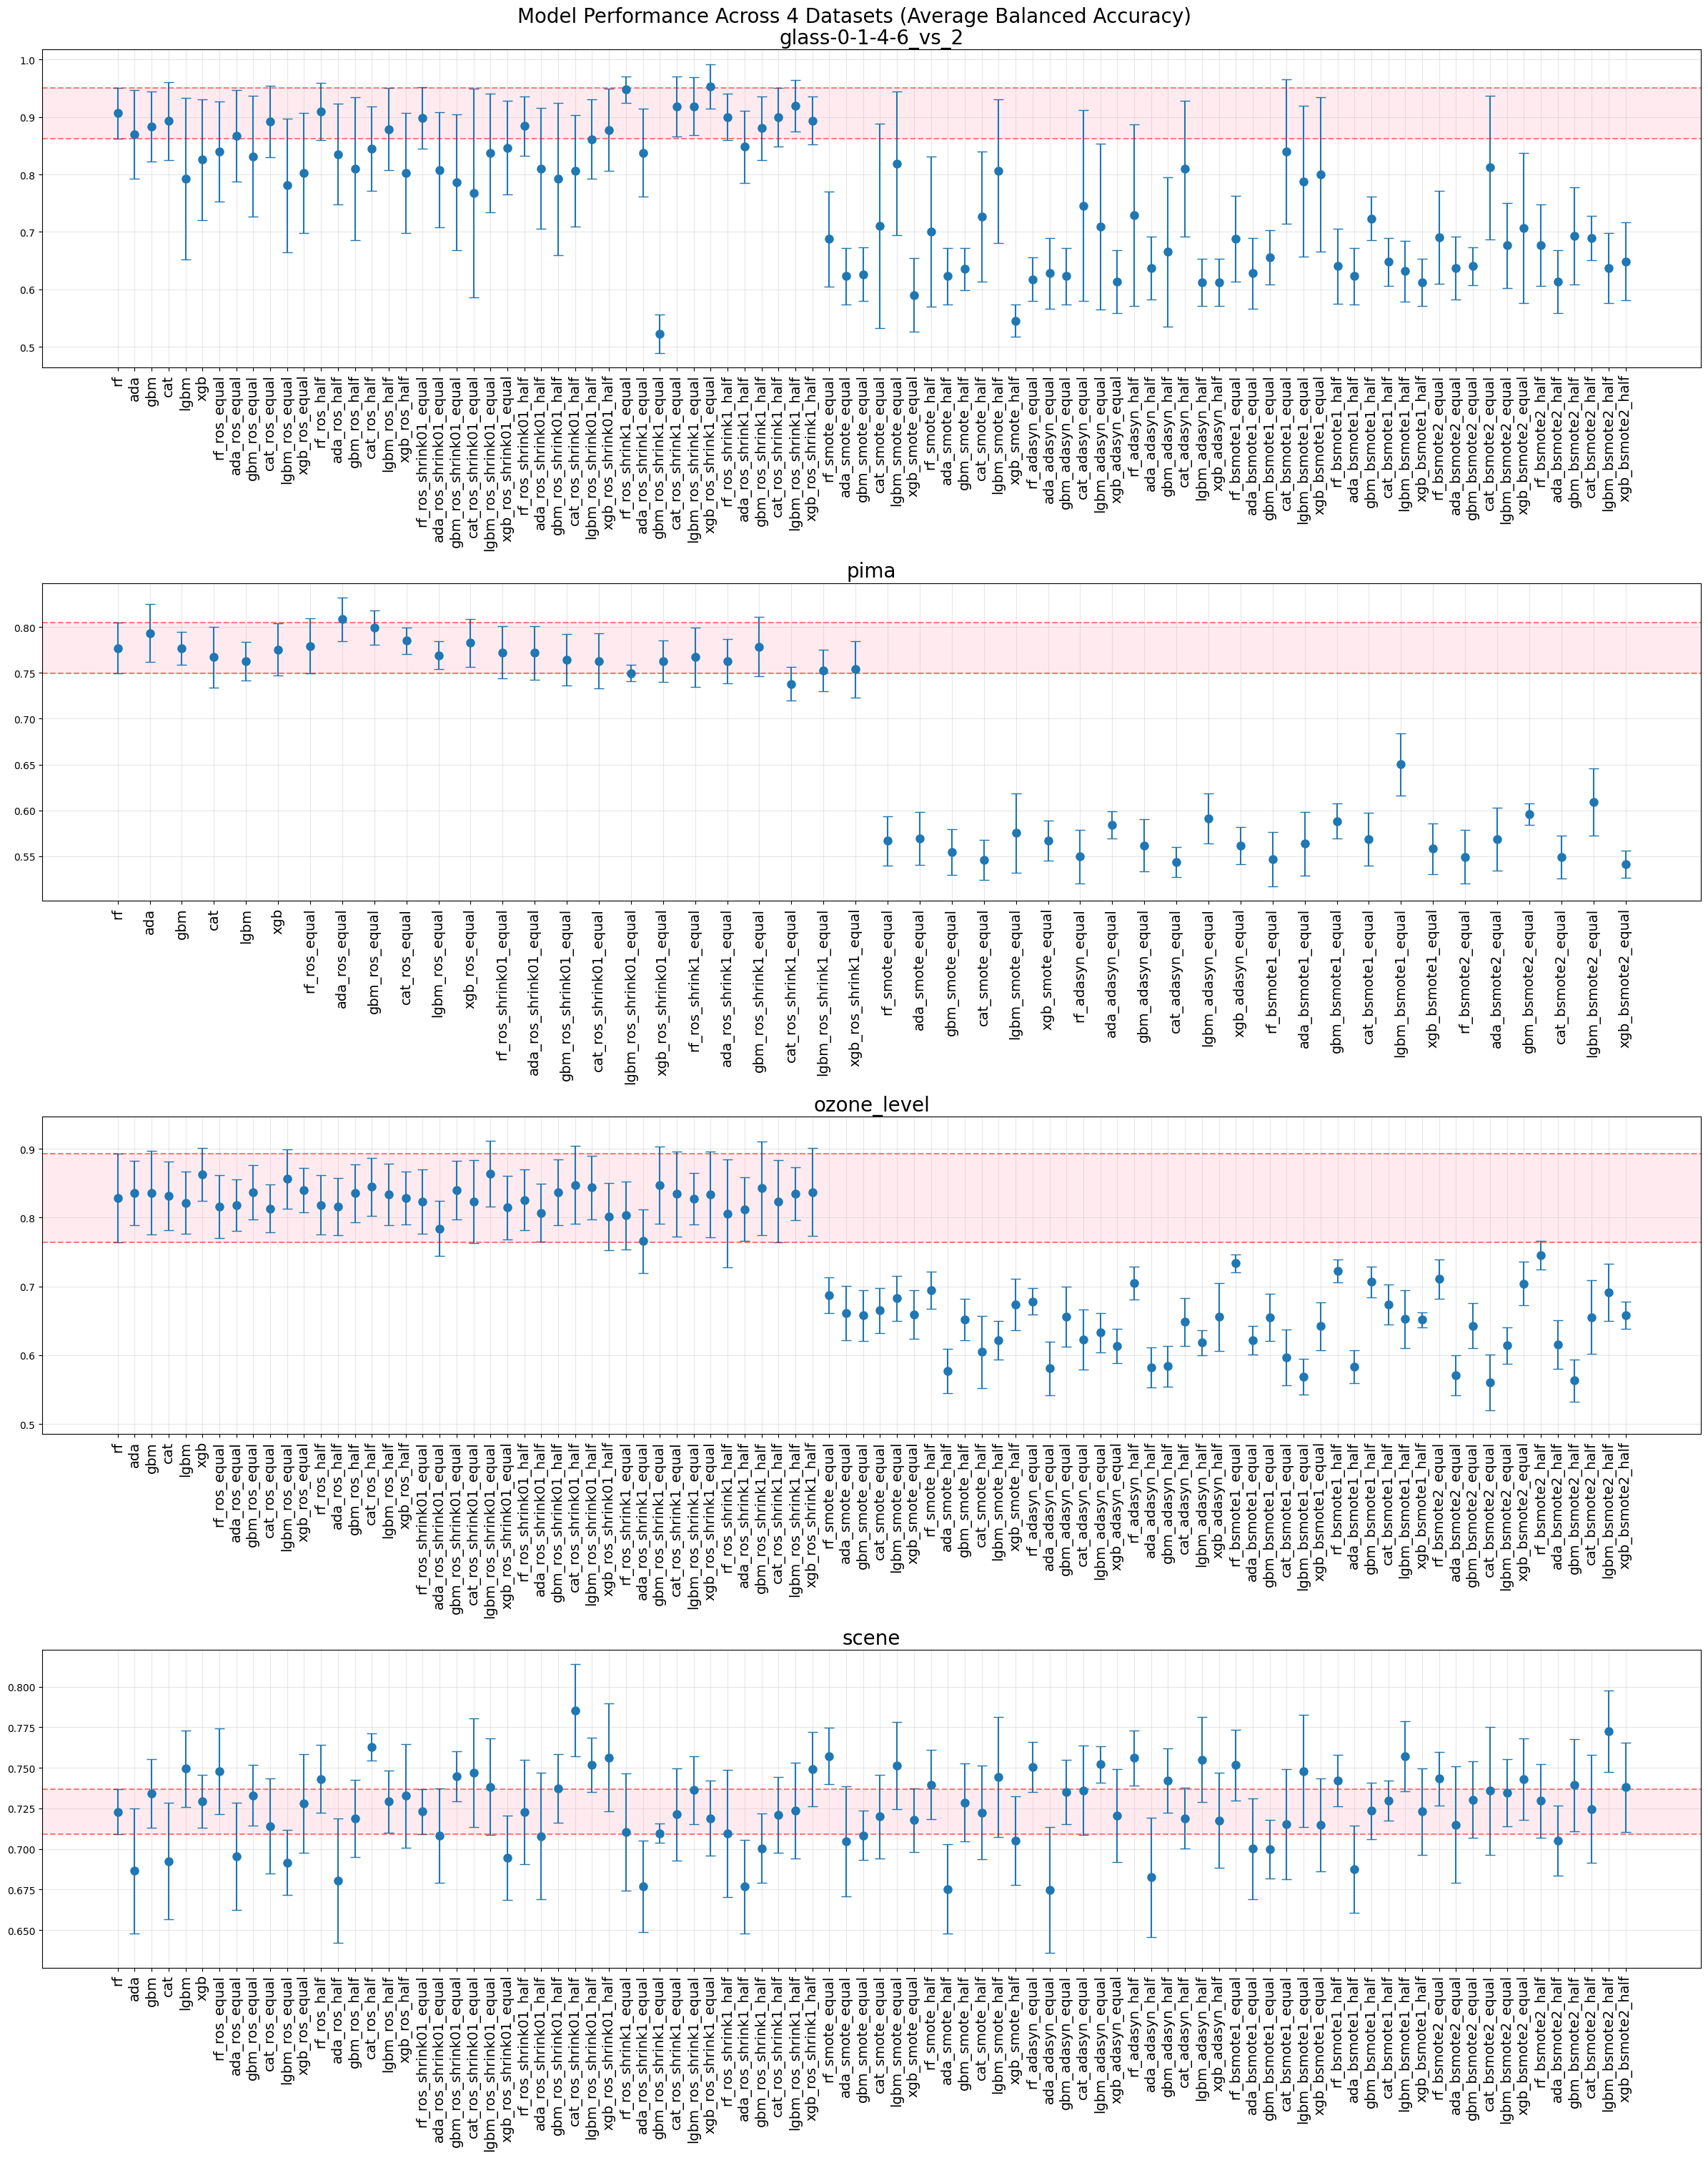

In [18]:
fig, axes = plt.subplots(nrows=len(datasets), ncols=1, figsize=(24, 30))
axes = axes.ravel()

for i, data in enumerate(datasets):
    models = scores_dict[data].keys()
    df = create_df(scores_dict, data, models)

    ax = axes[i]

    cls = df.index
    means = df.iloc[:, 12]
    stds = df.iloc[:, 13]

    upper = df.iloc[0, 12] + df.iloc[0, 13]
    lower = df.iloc[0, 12] - df.iloc[0, 13]

    ax.errorbar(x=cls, y=means, yerr=stds, fmt='o', capsize=5, markersize=8)

    ax.set_title(data, fontsize=20)
    ylims = compute_ylim(means, stds, upper, lower)
    ax.set_ylim(ylims)
    ax.tick_params(axis='x', rotation=90, labelsize=14)
    ax.grid(True, alpha=0.3)

    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

plt.tight_layout()
plt.suptitle('Model Performance Across 4 Datasets (Average Balanced Accuracy)', fontsize=20, y=1.005)
plt.savefig('../figures/os_ba.png', dpi=300, bbox_inches='tight')
plt.show()

## Brier score

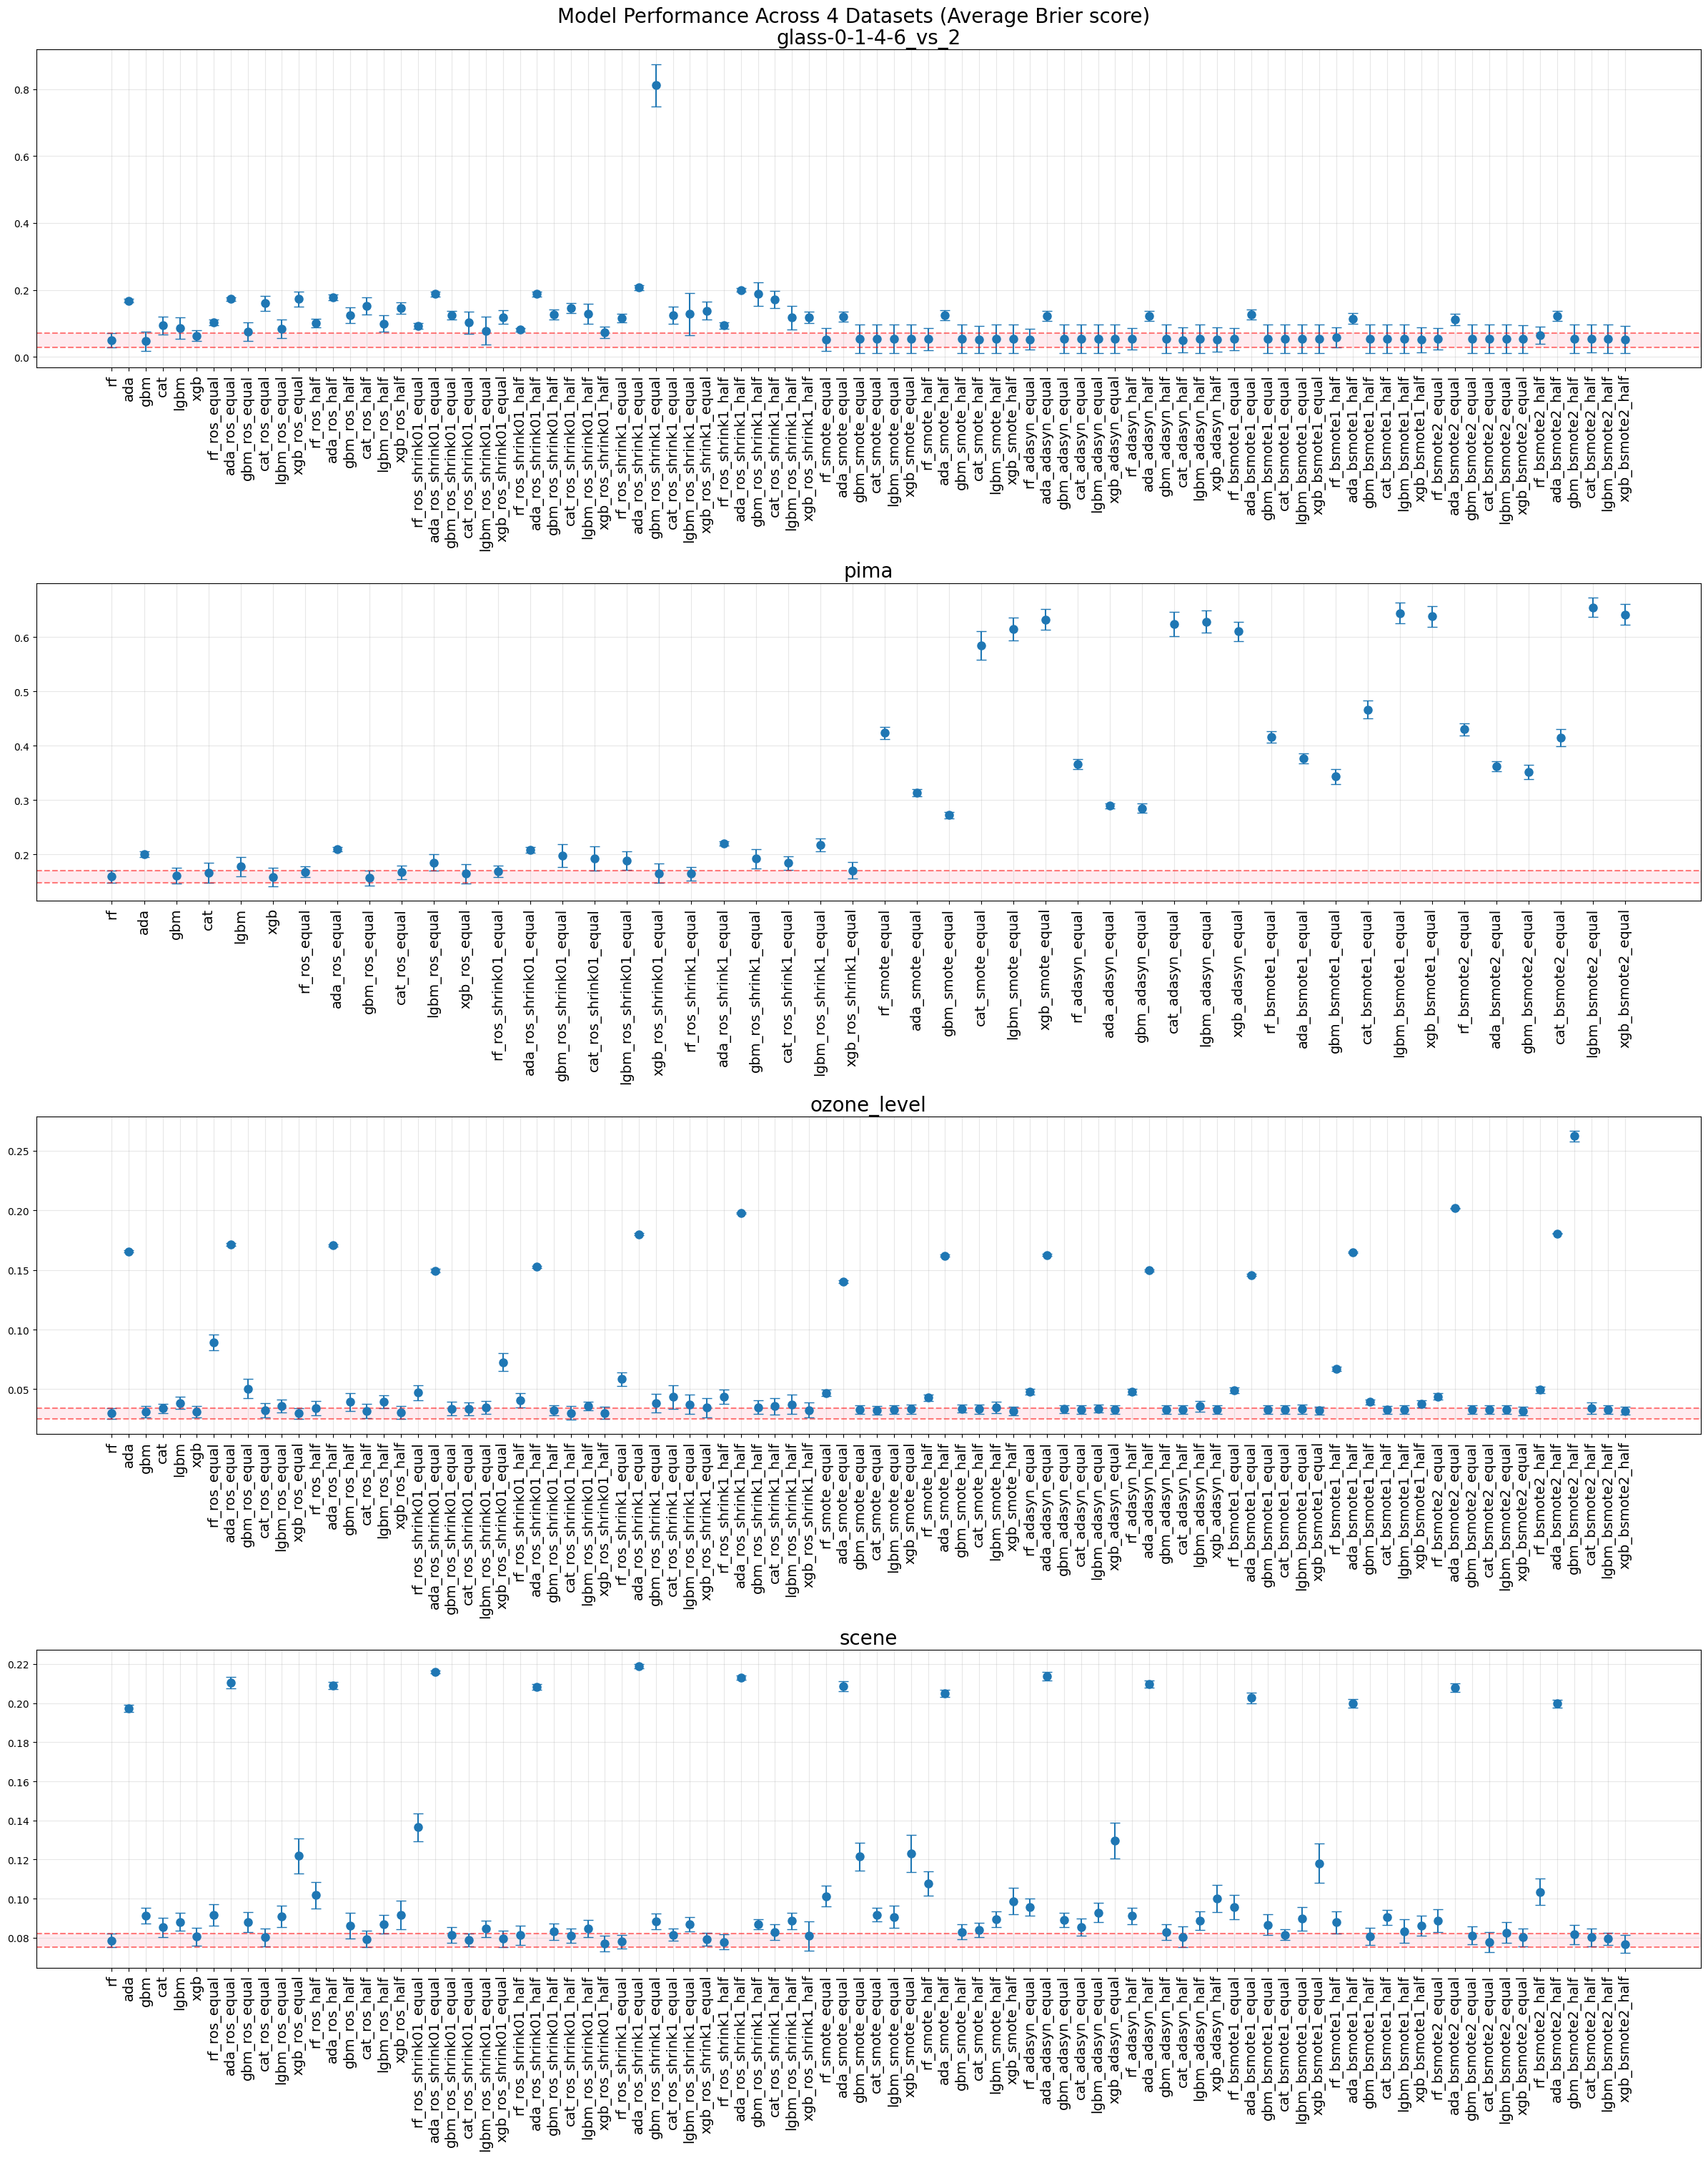

In [19]:
fig, axes = plt.subplots(nrows=len(datasets), ncols=1, figsize=(24, 30))
axes = axes.ravel()

for i, data in enumerate(datasets):
    models = scores_dict[data].keys()
    df = create_df(scores_dict, data, models)

    ax = axes[i]

    cls = df.index
    means = df.iloc[:, 14]
    stds = df.iloc[:, 15]

    upper = df.iloc[0, 14] + df.iloc[0, 15]
    lower = df.iloc[0, 14] - df.iloc[0, 15]

    ax.errorbar(x=cls, y=means, yerr=stds, fmt='o', capsize=5, markersize=8)

    ax.set_title(data, fontsize=20)
    ylims = compute_ylim(means, stds, upper, lower)
    ax.set_ylim(ylims)
    ax.tick_params(axis='x', rotation=90, labelsize=14)
    ax.grid(True, alpha=0.3)

    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

plt.tight_layout()
plt.suptitle('Model Performance Across 4 Datasets (Average Brier score)', fontsize=20, y=1.005)
plt.savefig('../figures/os_brier.png', dpi=300, bbox_inches='tight')
plt.show()

## Best oversampling variant per model and dataset
### ROC-AUC

In [20]:
best_performance_summary(scores_dict, datasets, metric='roc', metric_std='roc_std', factor=3)

,dataset,model,roc,roc_std,best_csl_variant,best_csl_roc,best_csl_roc_std,roc_diff
0,glass-0-1-4-6_vs_2,rf,0.828036,0.098593,rf_ros_shrink1_equal,0.917698,0.018941,0.089663
1,glass-0-1-4-6_vs_2,ada,0.760278,0.168297,ada_ros_equal,0.754722,0.172615,-0.005556
2,glass-0-1-4-6_vs_2,gbm,0.786667,0.126227,gbm_ros_shrink1_half,0.780952,0.116730,-0.005714
3,glass-0-1-4-6_vs_2,cat,0.798611,0.146065,cat_ros_shrink1_equal,0.868333,0.102403,0.069722
4,glass-0-1-4-6_vs_2,lgbm,0.612500,0.294903,lgbm_ros_shrink1_half,0.869266,0.090100,0.256766
5,glass-0-1-4-6_vs_2,xgb,0.704702,0.221488,xgb_ros_shrink1_equal,0.921488,0.072633,0.216786
6,pima,rf,0.825226,0.028167,rf_ros_shrink1_equal,0.819922,0.033403,-0.005303
7,pima,ada,0.843126,0.031516,ada_ros_equal,0.851682,0.028157,0.008556
8,pima,gbm,0.830616,0.023809,gbm_ros_equal,0.843253,0.029844,0.012637
9,pima,cat,0.821662,0.030829,cat_ros_equal,0.835986,0.021892,0.014325


### AP

In [21]:
best_performance_summary(scores_dict, datasets, metric='ap', metric_std='ap_std', factor=3)

,dataset,model,ap,ap_std,best_csl_variant,best_csl_ap,best_csl_ap_std,ap_diff
0,glass-0-1-4-6_vs_2,rf,0.312785,0.260841,rf_ros_shrink1_equal,0.389697,0.199571,0.076912
1,glass-0-1-4-6_vs_2,ada,0.359947,0.377165,ada_ros_half,0.368958,0.393566,0.009011
2,glass-0-1-4-6_vs_2,gbm,0.372821,0.373971,gbm_ros_equal,0.373590,0.395556,0.000770
3,glass-0-1-4-6_vs_2,cat,0.397633,0.394345,cat_ros_shrink1_equal,0.423122,0.354486,0.025489
4,glass-0-1-4-6_vs_2,lgbm,0.333000,0.377375,lgbm_ros_shrink1_half,0.343848,0.220337,0.010848
5,glass-0-1-4-6_vs_2,xgb,0.271091,0.251396,xgb_ros_shrink1_equal,0.611016,0.361869,0.339925
6,pima,rf,0.667815,0.030591,rf_ros_shrink1_equal,0.665577,0.035565,-0.002238
7,pima,ada,0.697430,0.057319,ada_ros_equal,0.701439,0.060535,0.004009
8,pima,gbm,0.671512,0.035444,gbm_ros_equal,0.710828,0.028278,0.039316
9,pima,cat,0.667280,0.059521,cat_ros_equal,0.696530,0.041622,0.029250


### Balanced accuracy

In [22]:
best_performance_summary(scores_dict, datasets, metric='ba', metric_std='ba_std', factor=3)

,dataset,model,ba,ba_std,best_csl_variant,best_csl_ba,best_csl_ba_std,ba_diff
0,glass-0-1-4-6_vs_2,rf,0.906518,0.044438,rf_ros_shrink1_equal,0.947599,0.022667,0.041081
1,glass-0-1-4-6_vs_2,ada,0.870139,0.077193,ada_ros_equal,0.867361,0.079191,-0.002778
2,glass-0-1-4-6_vs_2,gbm,0.883333,0.061237,gbm_ros_shrink1_half,0.880476,0.055821,-0.002857
3,glass-0-1-4-6_vs_2,cat,0.893056,0.067985,cat_ros_shrink1_equal,0.918542,0.052084,0.025486
4,glass-0-1-4-6_vs_2,lgbm,0.792500,0.140528,lgbm_ros_shrink1_half,0.919633,0.044719,0.127133
5,glass-0-1-4-6_vs_2,xgb,0.825962,0.105199,xgb_ros_shrink1_equal,0.953690,0.038665,0.127728
6,pima,rf,0.777096,0.027878,rf_ros_equal,0.779320,0.030195,0.002224
7,pima,ada,0.793482,0.031753,ada_ros_equal,0.808406,0.023890,0.014923
8,pima,gbm,0.777004,0.018066,gbm_ros_equal,0.799121,0.018710,0.022118
9,pima,cat,0.767114,0.032989,cat_ros_equal,0.785011,0.014736,0.017897


## Join datasets and create table

In [24]:
# dfs = [create_df(scores_dict, data, models) for data in datasets]
# result = pd.concat(dfs, keys=datasets, names=['dataset', 'model'])
# result

In [25]:
# result['roc_±_std'] = result['roc'].round(3).astype(str) + '±' + result['roc_std'].round(3).astype(str)
# result['ap_±_std'] = result['ap'].round(3).astype(str) + '±' + result['ap_std'].round(3).astype(str)
# result['recall_±_std'] = result['recall'].round(3).astype(str) + '±' + result['recall_std'].round(3).astype(str)
# result['thresh_±_std'] = result['thresh'].round(3).astype(str) + '±' + result['tresh_std'].round(3).astype(str)

# result.to_csv('../results/os_models_performance.csv', index=True)

# result[['roc_±_std', 'ap_±_std', 'recall_±_std', 'thresh_±_std']]